In [68]:
import numpy as np
import pandas as pd

In [69]:
df = pd.read_csv("F:/Jupyter_Projects/Phitron AL ML/Dataset/titanic_data_updated.csv")
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
591,592,yes,first,"Stephenson, Mrs. Walter Bertram (Martha Eustis)",female,52.0,1,0,36947,78.2667,D20,C
326,327,no,third,"Nysveen, Mr. Johan Hansen",male,61.0,0,0,345364,6.2375,NaN,S
754,755,yes,second,"Herman, Mrs. Samuel (Jane Laver)",female,48.0,1,2,220845,65.0000,NaN,S


In [70]:
df.shape

(891, 12)

In [71]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


1. Datatype	    Usually Needs

2. Numeric	    scaling

3. Categorical	encoding

4. Datetime	    feature extraction

5. Text	        NLP preprocessing

In [73]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891,891,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,2,3,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,no,third,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,549,491,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,NaN,NaN,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,NaN,NaN,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,NaN,NaN,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,NaN,NaN,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,NaN,NaN,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [74]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [77]:
df['Pclass'].unique()

array(['third', 'first', 'second'], dtype=object)

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

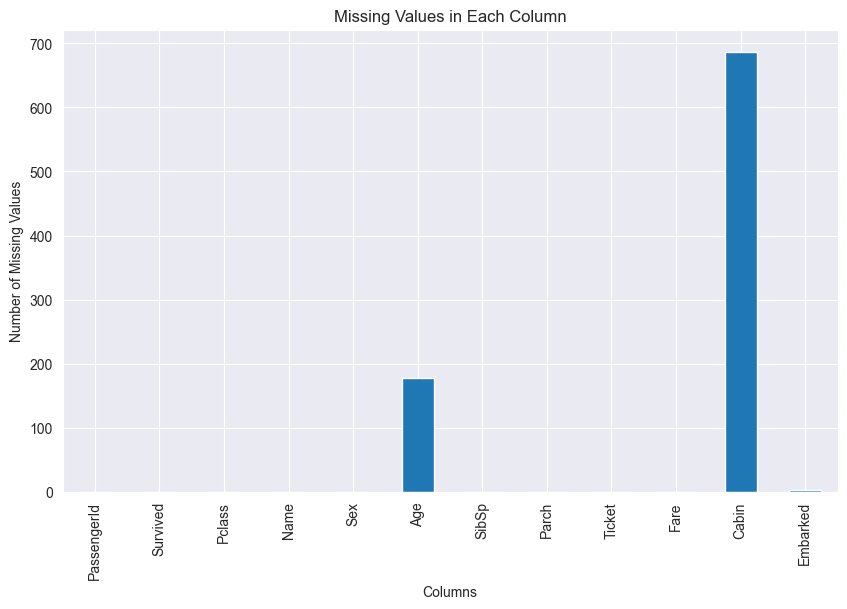

In [80]:
sns.set_style('darkgrid')
missing_values = df.isnull().sum()

missing_values.plot(kind='bar')
plt.title('Missing Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.show()

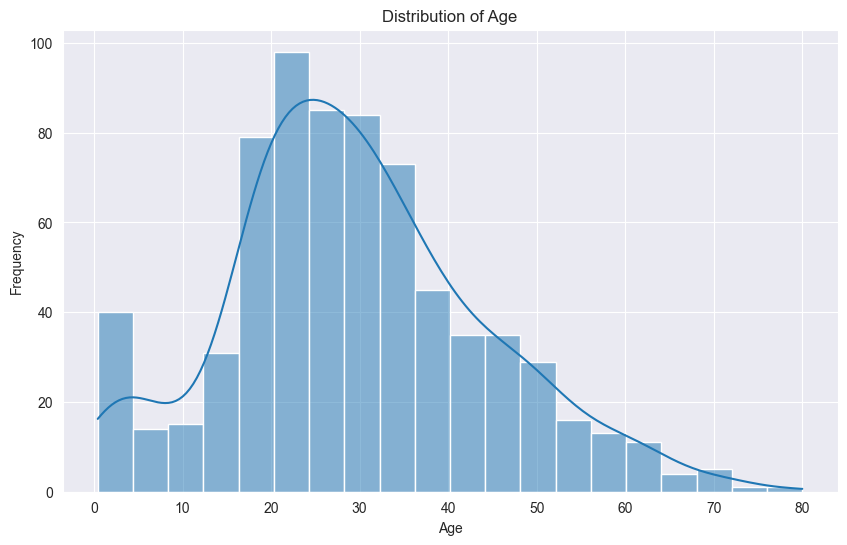

In [81]:
sns.histplot(data=df['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [82]:
# Age are almost normally distributed with some outliers on the right side.
# So i did here both normal distribution to detect the outliers and also a KDE plot to see the density of the data. and boxplot also, then compare which gives us better insight about the outliers.

average_age = df['Age'].mean()
std_age = df['Age'].std()

lower_bound = average_age - 3 * std_age
upper_bound = average_age + 3 * std_age

print(average_age, std_age, lower_bound, upper_bound)
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
outliers

29.69911764705882 14.526497332334042 -13.880374349943303 73.27860964406094


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
630,631,yes,first,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.000,A23,S
851,852,no,third,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.775,NaN,S


In [83]:
outliers.shape

(2, 12)

In [84]:
# Box plot for Age
median_age = df['Age'].median()
q1_age = df['Age'].quantile(0.25)
q3_age = df['Age'].quantile(0.75)
iqr_age = q3_age - q1_age
lower_bound_box = q1_age - 1.5 * iqr_age
upper_bound_box = q3_age + 1.5 * iqr_age
print(median_age, q1_age, q3_age, iqr_age, lower_bound_box, upper_bound_box)
outliers_box = df[(df['Age'] < lower_bound_box) | (df['Age'] > upper_bound_box)]
outliers_box

28.0 20.125 38.0 17.875 -6.6875 64.8125


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,no,second,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,no,first,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
96,97,no,first,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,no,third,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
280,281,no,third,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
456,457,no,first,"Millet, Mr. Francis Davis",male,65.0,0,0,13509,26.5500,E38,S
493,494,no,first,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,yes,first,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,no,second,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,no,first,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S


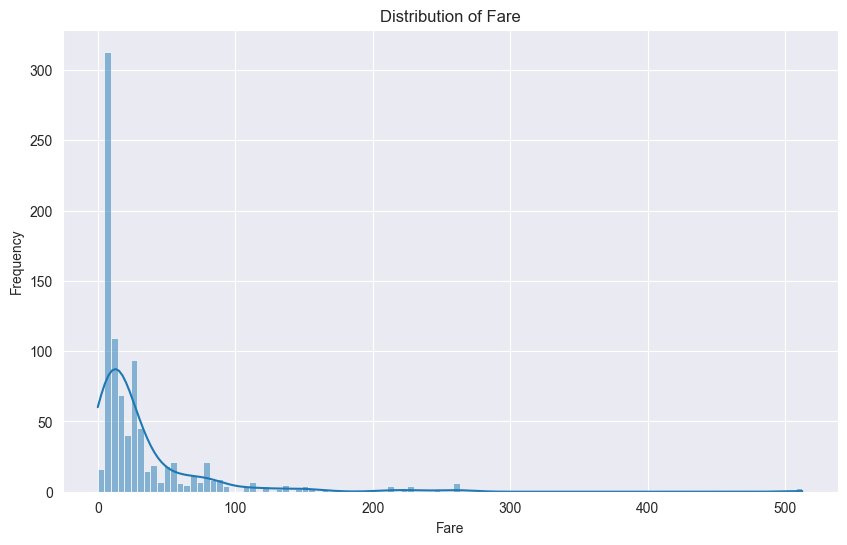

In [85]:
sns.histplot(data = df['Fare'], kde  = True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_2828\3425121588.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df['Fare'], shade = True)


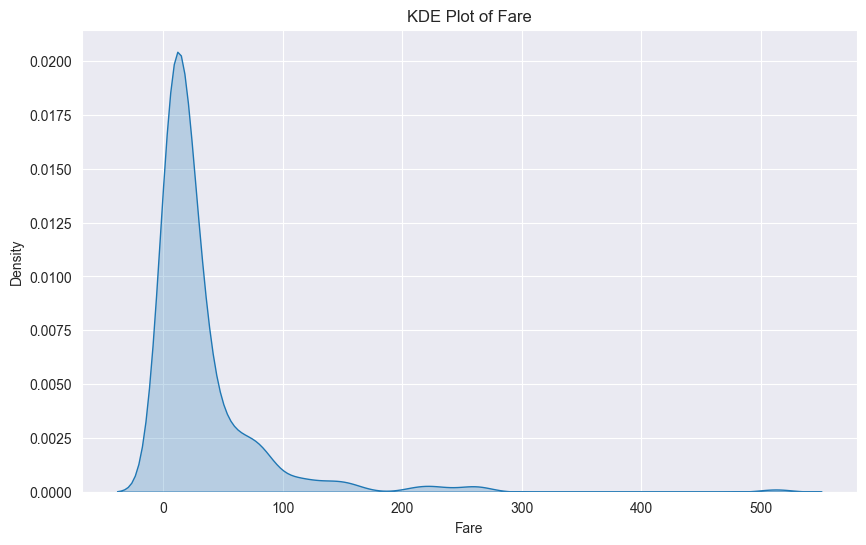

In [86]:
sns.kdeplot(data=df['Fare'], shade = True)
plt.title('KDE Plot of Fare')
plt.xlabel('Fare')
plt.ylabel('Density')
plt.show()

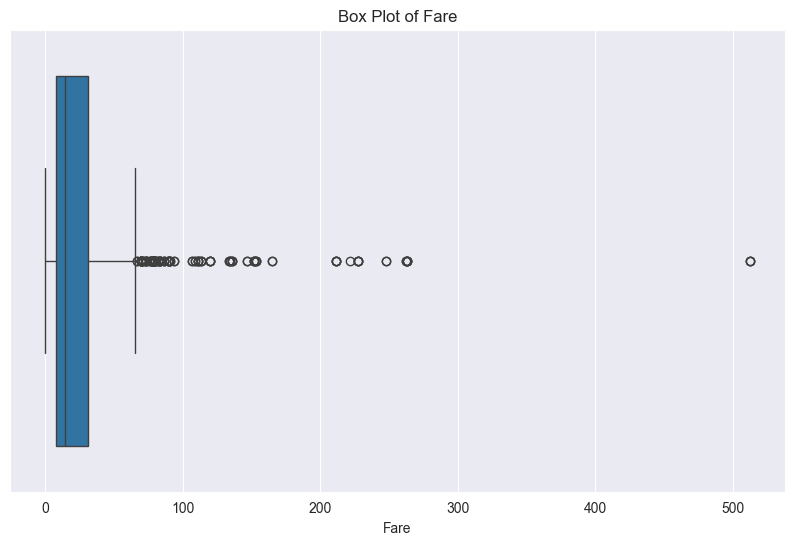

In [87]:
sns.boxplot(x = df['Fare'])
plt.title('Box Plot of Fare')
plt.xlabel('Fare')
plt.show()

In [88]:
df.shape

(891, 12)

<Axes: xlabel='Pclass', ylabel='count'>

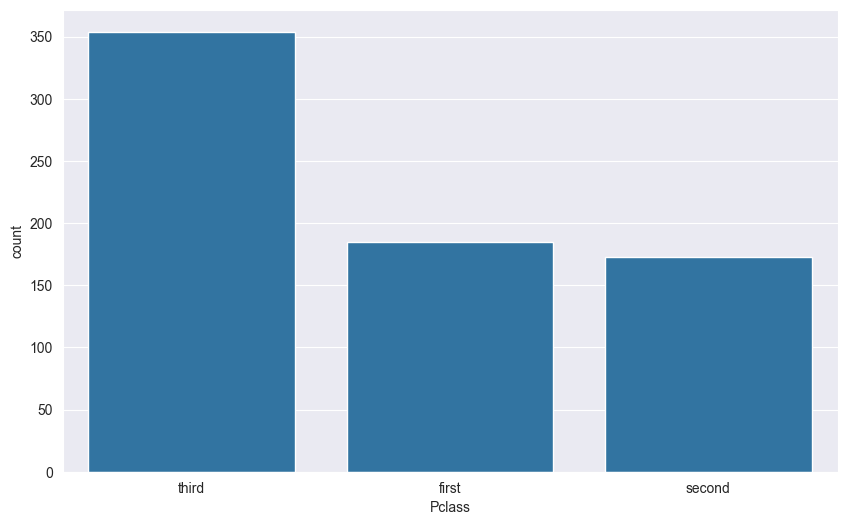

In [91]:
sns.countplot(data = df, x = 'Pclass')

<Axes: xlabel='Survived', ylabel='count'>

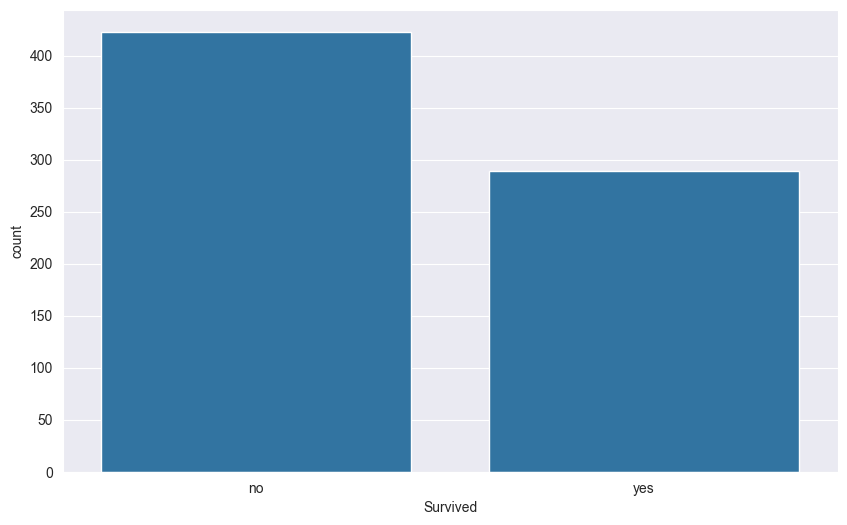

In [93]:
sns.countplot(data = df, x = 'Survived')

<Axes: xlabel='Sex', ylabel='count'>

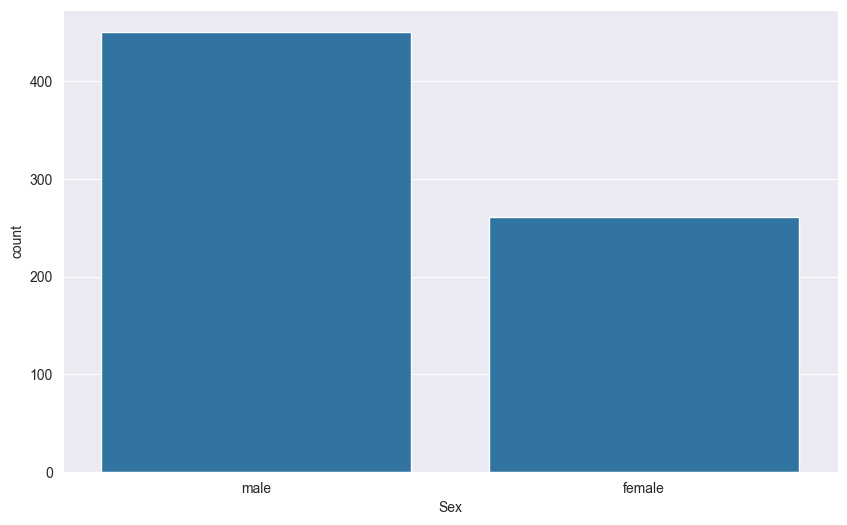

In [94]:
sns.countplot(data = df, x = 'Sex')

<Axes: xlabel='Embarked', ylabel='count'>

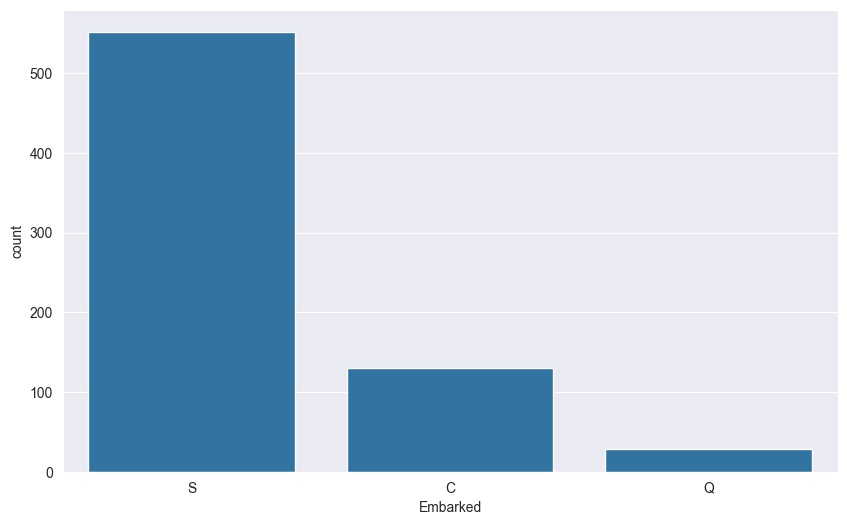

In [95]:
sns.countplot(data = df, x = 'Embarked')

<Axes: xlabel='Sex', ylabel='count'>

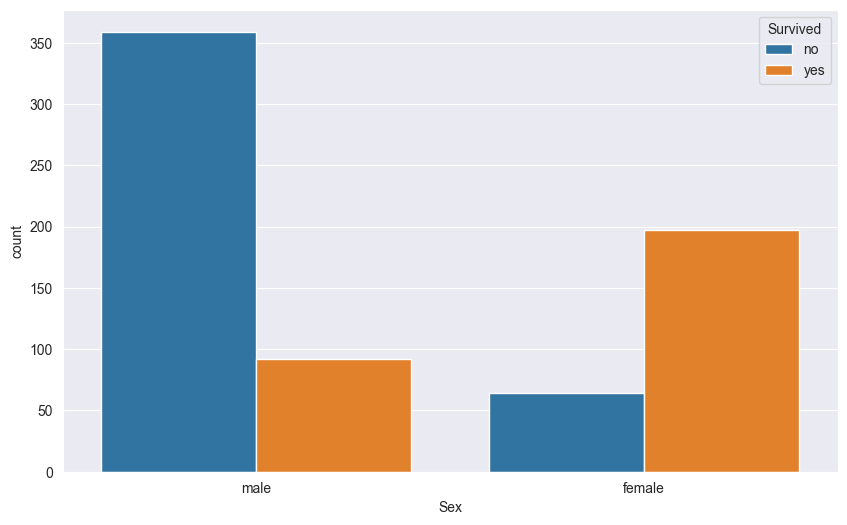

In [96]:
sns.countplot(data = df, x = 'Sex', hue = 'Survived')


<Axes: xlabel='Pclass', ylabel='count'>

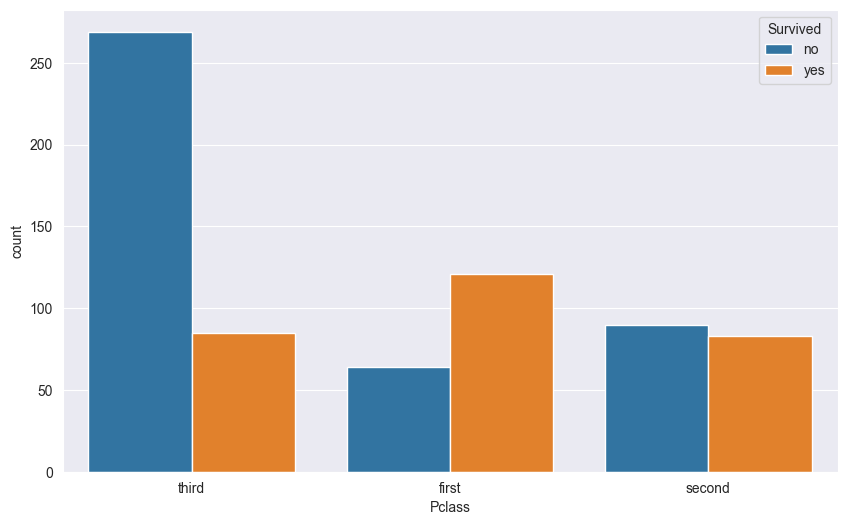

In [97]:
sns.countplot(data = df, x = 'Pclass', hue = 'Survived')

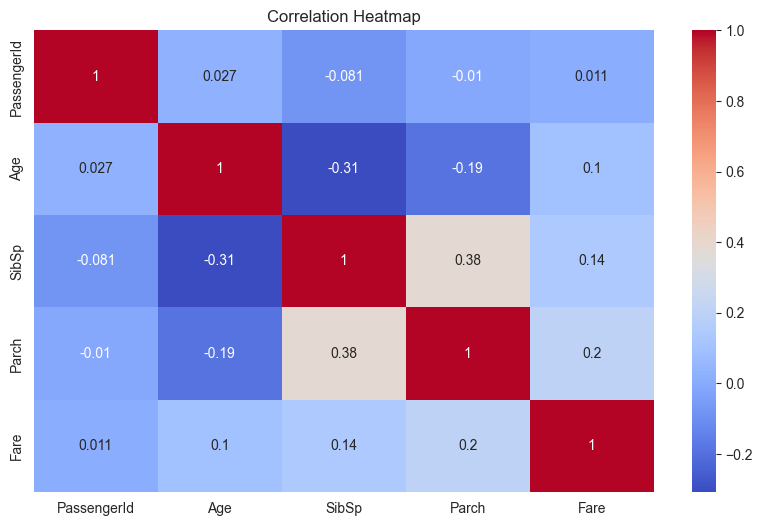

In [98]:
numeric_df = df.select_dtypes(include = ['int64','float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [100]:
df['Age'].mean()

np.float64(29.566249999999997)

In [101]:
df['Age'].median()

np.float64(28.0)

In [102]:
df['Age'].mode()

0    24.0
Name: Age, dtype: float64

In [103]:
df['Age'].std()

np.float64(14.327460257234852)

In [104]:
df['Age'].fillna(df['Age'].median(), inplace = True)

C:\Users\HP\AppData\Local\Temp\ipykernel_2828\3612560828.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace = True)


In [105]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [107]:
df['Embarked'].value_counts()

Embarked
S    552
C    130
Q     28
Name: count, dtype: int64

In [108]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)

In [109]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'D33', 'B30', 'B28', 'C83', 'F33', 'F G73', 'E31',
       'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101', 'D47', 'B86',
       'F2', 'C2', 'B19', 'A7', 'C49', 'F4', 'B4', 'B80', 'A31', 'D36',
       'D15', 'C93', 'C78', 'D35', 'C87', 'B77', 'E67', 'B94', 'C125',
       'C99', 'C118', 'D7', 'B49', 'D', 'C22 C26', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'E33', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'C52',
       'E44', 'A34', 'C104', 'C111', 'C92', 'E38', 'E12', 'E63', 'B37',
       'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'B38', 'B39', 'B22',
       'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68', 'B41', 'A20',
       'D19', 'D50', 'D9', 'B50', 'A26', 'D48', 'E58', 'B71',
       'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63', 'C62 C64', 'E24',
       'C90', 'C126', 'C45', 'E8', 'B101', 'C46', 'D30', 'E121', 'D11',
       'E77', 'B

In [111]:
df['Cabin'].isnull().sum()

np.int64(528)

In [112]:
df['Cabin'].fillna('Unknown', inplace = True)

In [113]:
df['Age'].median()

np.float64(28.0)

In [114]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

<Axes: >

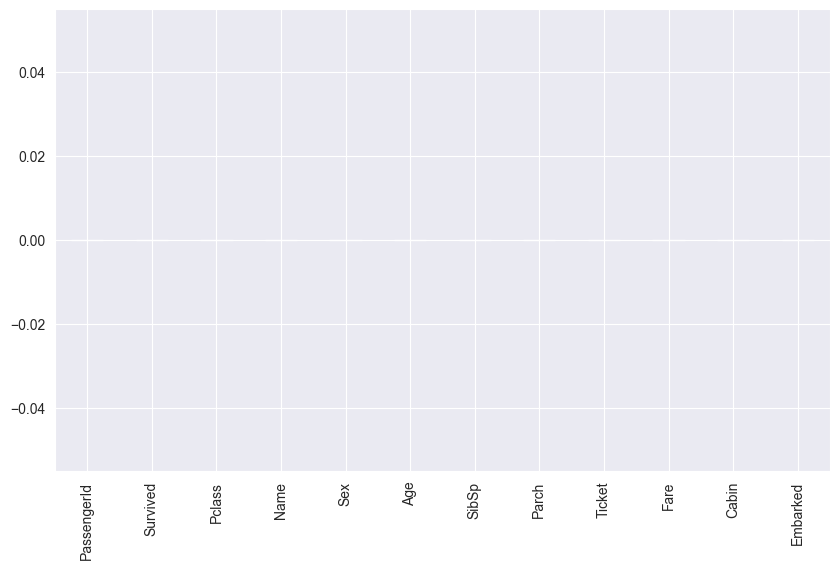

In [115]:
missing_values = df.isnull().sum()
missing_values.plot(kind = 'bar')

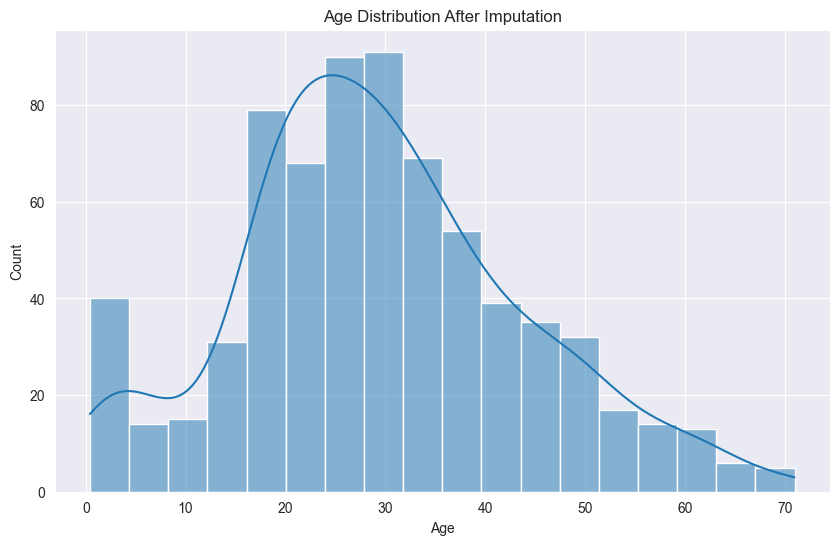

In [116]:
sns.histplot(df["Age"], kde=True)

plt.title("Age Distribution After Imputation")

plt.show()

In [117]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [119]:
df = pd.get_dummies(df, columns = ['Embarked'], drop_first = True)


In [120]:
oe = OrdinalEncoder(categories = [['third', 'second', 'first']])
df['Pclass'] = oe.fit_transform(df[['Pclass']])

In [121]:
df.sample(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
509,510,yes,0.0,"Lang, Mr. Fang",1,26.0,0,0,1601,56.4958,Unknown,False,True
72,73,no,1.0,"Hood, Mr. Ambrose Jr",1,21.0,0,0,S.O.C. 14879,73.5000,Unknown,False,True


In [123]:
df['Survived'] = le.fit_transform(df['Survived'])
df.sample(12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
333,334,0,0.0,"Vander Planke, Mr. Leo Edmondus",1,16.0,2,0,345764,18.0000,Unknown,False,True
349,350,0,0.0,"Dimic, Mr. Jovan",1,42.0,0,0,315088,8.6625,Unknown,False,True
91,92,0,0.0,"Andreasson, Mr. Paul Edvin",1,20.0,0,0,347466,7.8542,Unknown,False,True
505,506,0,2.0,"Penasco y Castellana, Mr. Victor de Satode",1,18.0,1,0,PC 17758,108.9000,C65,False,False
610,611,0,0.0,"Andersson, Mrs. Anders Johan (Alfrida Konstant...",0,39.0,1,5,347082,31.2750,Unknown,False,True
398,399,0,1.0,"Pain, Dr. Alfred",1,23.0,0,0,244278,10.5000,Unknown,False,True
731,732,0,0.0,"Hassan, Mr. Houssein G N",1,11.0,0,0,2699,18.7875,Unknown,False,False
68,69,1,0.0,"Andersson, Miss. Erna Alexandra",0,17.0,4,2,3101281,7.9250,Unknown,False,True
819,820,0,0.0,"Skoog, Master. Karl Thorsten",1,10.0,3,2,347088,27.9000,Unknown,False,True
823,824,1,0.0,"Moor, Mrs. (Beila)",0,27.0,0,1,392096,12.4750,E121,False,True
